> Name: Himanshu Dahire

> Batch ID: Data Science_05092024_10_AM(PDS_23072024)

In [ ]:
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

from wordcloud import WordCloud
from collections import Counter

import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dahir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dahir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dahir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dahir\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Options to avoid browser detection
options = Options()
options.add_argument("start-maximized")
# options.add_argument("--headless")  # Run Chrome in headless mode for efficiency
options.add_argument("--disable-gpu")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_experimental_option("excludeSwitches", ["enable-automation"])

In [3]:
def scrape_news_content(url: str):
    # Set headers to mimic a browser request
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    # Make the request
    response = requests.get(url, headers=headers)
    time.sleep(2) # wait for some time to load the page

    content = None
    if response.status_code == 200: # check for successful response

        # Parse the page
        soup = BeautifulSoup(response.text, "html.parser")

        # Find all <p> elements
        news_contents = soup.find_all("p")

        content = "\n".join([i.text for i in news_contents])

    return content


In [4]:
def get_news_contents(topic: str,
                    num_news_articles = 20):

    # Creating Web driver instance for chrome
    driver = webdriver.Chrome(options=options)

    # fetching google webpage
    driver.get("https://www.google.com/")

    # Searching for the news 
    text_box = driver.find_element(by = "name", value="q")
    text_box.send_keys(topic + " news in english")
    text_box.submit()

    time.sleep(2)

    # Going to the news tab
    news_tab = driver.find_element(by = "link text", value="News")
    news_tab.click()

    news_articles = []

    while True:
        
        break_while = False

        for i in driver.find_elements(by="class name", value="WlydOe"):
            url = i.get_attribute("href")
            
            content = scrape_news_content(url)

            # Check the number of news articles
            if len(news_articles) == num_news_articles:
                break_while = True
                break
            else:
                # check if content is empty or not
                if  content is None or len(content) < 200:
                    continue
                else:
                    news_articles.append(content)
        
        # if enough news articles break the while loop
        if break_while:
            break

        # Going to next page
        next_page = driver.find_element(by = "link text", value = "Next")
        next_page.click()

    driver.quit()
    return news_articles

In [5]:
"""
import streamlit as st
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException
import time

def get_news_contents(topic: str, num_news_articles: int = 20):

    # Set up WebDriver options (assuming Chrome)
    options = webdriver.ChromeOptions()
    options.add_argument('--headless')  # Run in background
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')

    # Initialize Streamlit progress
    progress_bar = st.progress(0, text="Searching for news articles...")

    try:
        # Create WebDriver instance
        with webdriver.Chrome(options=options) as driver:
            # Navigate to Google
            driver.get("https://www.google.com/")
            
            # Search for news
            search_box = WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.NAME, "q"))
            )
            search_box.send_keys(f"{topic} news in english")
            search_box.submit()

            # Wait for and click News tab
            news_tab = WebDriverWait(driver, 10).until(
                EC.element_to_be_clickable((By.LINK_TEXT, "News"))
            )
            news_tab.click()

            # Initialize news collection
            news_articles = []
            page_num = 0

            while len(news_articles) < num_news_articles:
                # Update progress
                progress = min(len(news_articles) / num_news_articles, 1.0)
                progress_bar.progress(progress, 
                    text=f"Collecting articles: {len(news_articles)}/{num_news_articles}")

                # Find news article links
                article_links = driver.find_elements(By.CLASS_NAME, "WlydOe")
                
                for link in article_links:
                    try:
                        url = link.get_attribute("href")
                        content = scrape_news_content(url)

                        # Filter out invalid content
                        if content and len(content) >= 200:
                            news_articles.append(content)

                        # Check if we've reached the desired number of articles
                        if len(news_articles) >= num_news_articles:
                            break

                    except Exception as e:
                        st.warning(f"Error scraping article: {e}")
                        continue

                # If we've reached desired articles, break
                if len(news_articles) >= num_news_articles:
                    break

                # Try to navigate to next page
                try:
                    next_page = WebDriverWait(driver, 5).until(
                        EC.element_to_be_clickable((By.LINK_TEXT, "Next"))
                    )
                    next_page.click()
                    page_num += 1
                    time.sleep(2)  # Brief pause to allow page to load
                except (TimeoutException, NoSuchElementException):
                    st.warning("No more pages available.")
                    break

            # Final progress update
            progress_bar.progress(1.0, text="News collection complete!")
            
            return news_articles

    except Exception as e:
        st.error(f"An error occurred: {e}")
        return []
"""

'\nimport streamlit as st\nfrom selenium import webdriver\nfrom selenium.webdriver.common.by import By\nfrom selenium.webdriver.support.ui import WebDriverWait\nfrom selenium.webdriver.support import expected_conditions as EC\nfrom selenium.common.exceptions import TimeoutException, NoSuchElementException\nimport time\n\ndef get_news_contents(topic: str, num_news_articles: int = 20):\n\n    # Set up WebDriver options (assuming Chrome)\n    options = webdriver.ChromeOptions()\n    options.add_argument(\'--headless\')  # Run in background\n    options.add_argument(\'--no-sandbox\')\n    options.add_argument(\'--disable-dev-shm-usage\')\n\n    # Initialize Streamlit progress\n    progress_bar = st.progress(0, text="Searching for news articles...")\n\n    try:\n        # Create WebDriver instance\n        with webdriver.Chrome(options=options) as driver:\n            # Navigate to Google\n            driver.get("https://www.google.com/")\n            \n            # Search for news\n      

In [6]:
def text_preprocessing(text: str):
    """"
    text: list
        String of text to be tokenized
    """

    stop_words = set(stopwords.words('english'))

    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Remove stopwords
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    
    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Join the tokens to form a string
    processed_text = " ".join(lemmatized_tokens)

    return processed_text

def get_sentiment(text: str):
    """
    text: str
        String of text to be analyzed
    """

    sia = SentimentIntensityAnalyzer()
    
    # pre-processing the text
    processed_text = text_preprocessing(text)
    
    sentiment = sia.polarity_scores(processed_text)

    # Classify the sentiment
    result = "Positive" if sentiment['compound'] > 0.05 else "Negative" if sentiment['compound'] < -0.05 else "Neutral"
    
    return result

In [ ]:
def plot_sentiment_analysis(news_articles, news_title: str):    
    result = {"Positive": 0, "Negative": 0, "Neutral": 0}

    for article in news_articles:
        sentiment = get_sentiment(article)

        result[sentiment] += 1

    fig, ax = plt.subplots(figsize=(8, 6))
            
    # Color palette
    colors = ['#2ecc71', '#e74c3c', '#3498db']  # Green for Positive, Red for Negative, Blue for Neutral
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        result.values(), 
        labels=result.keys(), 
        autopct='%1.1f%%',
        colors=colors,
        # Explode slightly to make chart more readable
        explode=[0.1 if value > 0 else 0 for value in result.values()]
    )

    # Enhance text properties
    plt.setp(autotexts, size=9, weight="bold")
    plt.setp(texts, size=10)
    
    # Set title
    plt.title(f"Sentiment Analysis of {news_title}", fontsize=12, fontweight='bold')
    
    # Add legend with absolute numbers
    legend_labels = [f"{key}: {value}" for key, value in result.items()]
    plt.legend(wedges, legend_labels, title="Sentiment Counts", loc="upper right")
    
    # Adjust layout to prevent cutting off legend
    plt.tight_layout()

In [ ]:
def plot_unigram_worldCloud(tokens):
    # Create unigram word cloud

    # Create a dictionary of words and their frequency
    word_freq = Counter(tokens.split())

    # Create a word cloud
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          max_words=50, 
                          colormap='viridis').generate_from_frequencies(word_freq)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
        
    # Plot the WordCloud
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Unigram Word Cloud of News Content')
    
    # Ensure tight layout
    plt.tight_layout(pad=0)

In [ ]:
def plot_bigram_wordCloud(tokens):
    from nltk import bigrams

    # Create a list of bigrams
    bi_grams = list(bigrams(tokens.split()))

    # Create a dictionary of bigrams and their frequency
    bi_gram_freq = {" ".join(bigram): freq for bigram, freq in Counter(bi_grams).items()}

    wordcloud = WordCloud(width=800, height=400, 
                            background_color='white', 
                            max_words=50, 
                            colormap='viridis').generate_from_frequencies(bi_gram_freq)
        
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
        
    # Plot the WordCloud
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Bigram Word Cloud of News Content')
    
    # Ensure tight layout
    plt.tight_layout(pad=0)


In [10]:
def main_function(topic: str):
    # Get news articles
    news_articles = get_news_contents(topic)
    print(len(news_articles))

    # Plot the sentiment analysis
    plot_sentiment_analysis(news_articles, topic)

    # What is the combined sentiment of all the news articles?
    all_articles = " ".join(news_articles)

    print("Overall sentiment is ", get_sentiment(all_articles))

    # PLotting the unigram and bigram word cloud

    processed_text = text_preprocessing(all_articles)
    plot_unigram_worldCloud(processed_text)
    plot_bigram_wordCloud(processed_text)

20


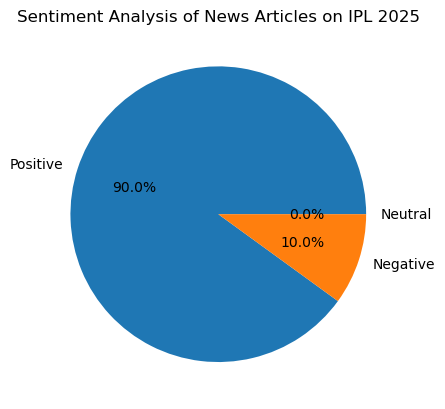

2025-03-25 13:19:28.506 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:29.199 
  command:

    streamlit run c:\Users\dahir\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-03-25 13:19:29.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:29.200 
Calling `st.pyplot()` without providing a figure argument has been deprecated
and will be removed in a later version as it requires the use of Matplotlib's
global figure object, which is not thread-safe.

To future-proof this code, you should pass in a figure as shown below:

```python
fig, ax = plt.subplots()
ax.scatter([1, 2, 3], [1, 2, 3])
# other plotting actions...
st.pyplot(fig)
```

If you have a specific use case that requires this functionality, please let us
know via [issue on Github](https://github.com/streamlit/streamlit/issues).

2025-03-25 13:19:29.201 Thread 'MainThread

Overall sentiment is  Positive


<Figure size 640x480 with 0 Axes>

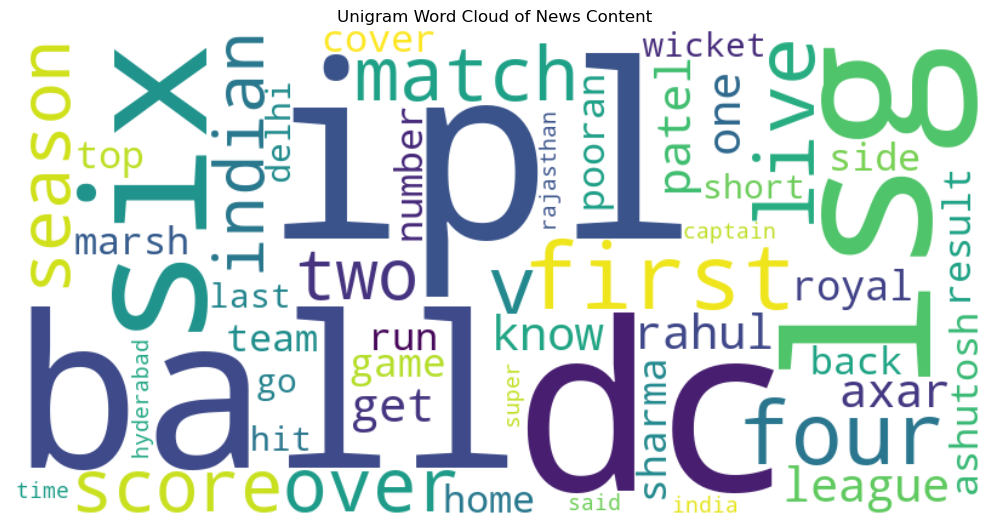

2025-03-25 13:19:30.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:30.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:30.639 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `use_container_width` parameter instead.
2025-03-25 13:19:30.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:30.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:30.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


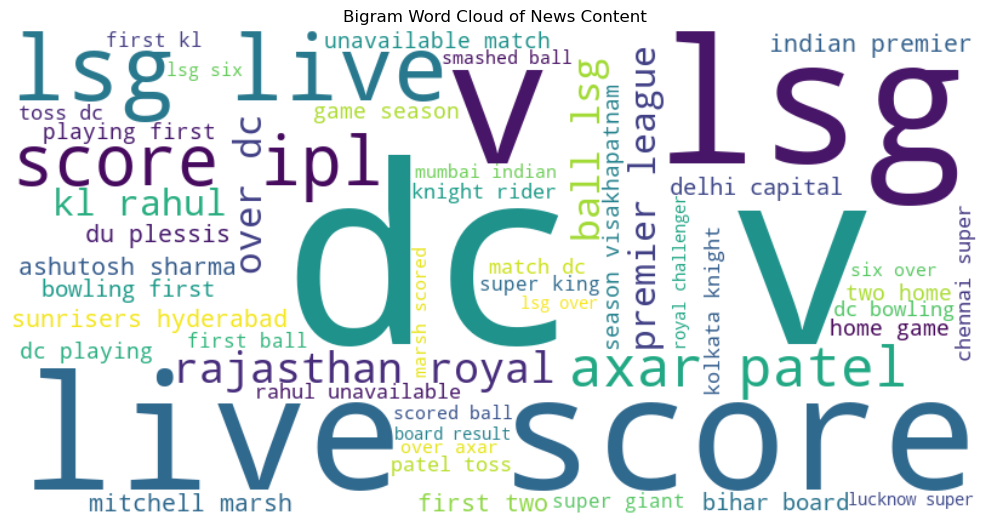

2025-03-25 13:19:31.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:31.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:31.116 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `use_container_width` parameter instead.
2025-03-25 13:19:31.121 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:31.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 13:19:31.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [11]:
main_function("IPL 2025")